In [19]:
import torch
import torch.nn as nn
import numpy as np
import math
import time

# Load frozen embedding table
embedding_table = np.load("tokenizer/token_embeddings.npy")
embedding_tensor = torch.tensor(embedding_table, dtype=torch.float32)

VOCAB_SIZE    = embedding_tensor.shape[0]   # 4096
MINILM_DIM    = embedding_tensor.shape[1]   # 384
print(f"Vocab size : {VOCAB_SIZE}")
print(f"MiniLM dim : {MINILM_DIM}")

Vocab size : 16384
MiniLM dim : 384


In [20]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ─── CONFIG ─────────────────────────────────────────────

EXPANDED_DIM = 512
N_HEADS      = 4
N_LAYERS     = 4
FFN_DIM      = 1024

# HEAD_DIM is now based on EXPANDED_DIM, not old DIM=384
HEAD_DIM = EXPANDED_DIM // N_HEADS

assert EXPANDED_DIM % N_HEADS == 0, "EXPANDED_DIM must be divisible by N_HEADS"


# ─── POSITIONAL ENCODING ────────────────────────────────

def sinusoidal_encoding(seq_len, dim, device):
    pe = torch.zeros(seq_len, dim, device=device)

    position = torch.arange(seq_len, device=device).unsqueeze(1)

    div_term = torch.exp(
        torch.arange(0, dim, 2, device=device)
        * (-math.log(10000.0) / dim)
    )

    pe[:, 0::2] = torch.sin(position * div_term)

    if dim % 2 == 0:
        pe[:, 1::2] = torch.cos(position * div_term)
    else:
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])

    return pe  # (seq_len, dim)


# ─── MODEL ───────────────────────────────────────────────

class MicroLM(nn.Module):
    """
    MicroLM using PyTorch built-in TransformerEncoderLayer.

    Flow:
      token_ids
        -> trainable token embedding table
        -> sinusoidal positional encoding
        -> N transformer encoder layers with causal mask
        -> final LayerNorm
        -> output_head
    """

    def __init__(self):
        super().__init__()

        # Trainable embedding from scratch
        self.token_embedding = nn.Embedding(
            num_embeddings=VOCAB_SIZE,
            embedding_dim=EXPANDED_DIM
        )

        # Transformer block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=EXPANDED_DIM,
            nhead=N_HEADS,
            dim_feedforward=FFN_DIM,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.blocks = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=N_LAYERS
        )

        self.norm = nn.LayerNorm(EXPANDED_DIM)

        self.output_head = nn.Linear(
            EXPANDED_DIM,
            VOCAB_SIZE,
            bias=False
        )

        # Optional but recommended for small GPT-style models:
        # tie input embedding and output projection weights.
        # This only works because both have shape [VOCAB_SIZE, EXPANDED_DIM].
        self.output_head.weight = self.token_embedding.weight

    def make_causal_mask(self, T, device):
        """
        PyTorch Transformer expects mask shape: (T, T)

        True means blocked when using bool mask.
        Upper triangle = future tokens blocked.
        """
        return torch.triu(
            torch.ones(T, T, device=device, dtype=torch.bool),
            diagonal=1
        )

    def forward(self, token_ids):
        B, T = token_ids.shape

        # (B, T, EXPANDED_DIM)
        x = self.token_embedding(token_ids)

        # Add sinusoidal positional encoding
        pos = sinusoidal_encoding(T, EXPANDED_DIM, token_ids.device)
        x = x + pos.unsqueeze(0)

        # Causal mask for GPT-style left-to-right training
        causal_mask = self.make_causal_mask(T, token_ids.device)

        # (B, T, EXPANDED_DIM)
        x = self.blocks(x, mask=causal_mask)

        x = self.norm(x)

        # (B, T, VOCAB_SIZE)
        logits = self.output_head(x)

        return logits

In [21]:
model     = MicroLM()
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}  (embedding table)")
print(f"Total params     : {total:,}")

# print(f"\nParam breakdown:")
# for name, p in model.named_parameters():
#     if p.requires_grad:
#         print(f"  {name:55s} {p.numel():>10,}")

# Forward pass
x      = torch.randint(0, VOCAB_SIZE, (2, 32))
logits = model(x)
print(f"\nInput  : {x.shape}")
print(f"Output : {logits.shape}")

Trainable params : 16,800,768
Frozen params    : 0  (embedding table)
Total params     : 16,800,768

Input  : torch.Size([2, 32])
Output : torch.Size([2, 32, 16384])


d:\Anaconda3\envs\jarvis\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [22]:
total     = sum(p.numel() for p in model.token_embedding.parameters())
trainable = sum(p.numel() for p in model.token_embedding.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}  (embedding table)")
print(f"Total params     : {total:,}")


Trainable params : 8,388,608
Frozen params    : 0  (embedding table)
Total params     : 8,388,608


In [23]:
5_515_264 - 4_194_304

1320960

In [24]:
# ── Training Config ───────────────────────────────────────────────────────────
import gc
import json
import random
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

SHARD_DIR  = Path("dataset_shards")
SEQ_LEN    = 512
STRIDE  = 256    # step size → 64-token overlap
BATCH_SIZE = 32
N_EPOCHS   = 100
LOG_EVERY  = 200
CKPT_DIR   = Path("checkpoints_v2")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

Device      : cuda
Model params: 16,800,768


In [25]:
from torch.utils.data import Dataset


class ShardDataset(Dataset):
    def __init__(self, shard_path, seq_len=SEQ_LEN, stride=STRIDE):
        flat = torch.load(shard_path, weights_only=True)

        self.flat    = flat.to(torch.int16)
        print(len(self.flat))
        self.flat    = self.flat[:20_000_000]
        print(len(self.flat))
        self.seq_len = seq_len
        self.stride  = stride

        # number of full windows we can extract
        # +1 because we need seq_len+1 tokens (x + y target)
        n_tokens = len(self.flat)
        self.num_samples = max(0, (n_tokens - seq_len - 1) // stride + 1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        start  = idx * self.stride
        tokens = self.flat[start : start + self.seq_len + 1].to(torch.long)  # ← cast here
        
        if len(tokens) < self.seq_len + 1:
            pad    = torch.full((self.seq_len + 1 - len(tokens),), PAD_ID, dtype=torch.long)
            tokens = torch.cat([tokens, pad])

        x = tokens[:-1]
        y = tokens[1:]
        return x, y


BOS_ID       = 2
EOS_ID       = 3

def collate_fn(batch):
    xs, ys = zip(*batch)
    # all samples are now fixed-length (seq_len), so no padding needed here
    x_pad = torch.stack(xs)          # [B, seq_len]
    y_pad = torch.stack(ys).clone()  # [B, seq_len]
    return x_pad, y_pad

In [26]:
2,684,361,59

(2, 684, 361, 59)

In [27]:
# run once after sharding
meta = {
    "total_samples": sum(len(ShardDataset(p)) for p in sorted(SHARD_DIR.glob("shard_*.pt"))[:1]),
    "seq_len": SEQ_LEN,
    "stride": STRIDE,
}
with open(SHARD_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)
    
# ── Optimizer & Scheduler ─────────────────────────────────────────────────────

with open(SHARD_DIR / "meta.json") as f:
    meta = json.load(f)

total_steps = (meta['total_samples'] // BATCH_SIZE) * N_EPOCHS

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scaler    = torch.cuda.amp.GradScaler()

print(f"Total samples: {meta['total_samples']:,}")
print(f"Total steps  : {total_steps:,}")

268436159
20000000
Total samples: 78,123
Total steps  : 244,100


C:\Users\Medhavi Monish\AppData\Local\Temp\ipykernel_39408\4277151627.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


In [28]:
sorted(SHARD_DIR.glob("shard_*.pt"))[:1]

[WindowsPath('dataset_shards/shard_0000.pt')]

In [29]:
model.to(device)

MicroLM(
  (token_embedding): Embedding(16384, 512)
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1024, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (output_head): Linear(in_features=512, out_features=16384, bias=False)
)

In [30]:
shard_files  = sorted(SHARD_DIR.glob("shard_*.pt"))[:1]
# shard_files.extend(sorted(SHARD_DIR.glob("ins*.pt"))[:1])
# shard_files.extend(sorted(SHARD_DIR.glob("shard_*.pt"))[1:2])
shard_files

[WindowsPath('dataset_shards/shard_0000.pt')]

In [37]:
all_ckpts = sorted(CKPT_DIR.glob("epoch_*.pt"))
all_ckpts

[WindowsPath('checkpoints_v2/epoch_1.pt'),
 WindowsPath('checkpoints_v2/epoch_10.pt'),
 WindowsPath('checkpoints_v2/epoch_11.pt'),
 WindowsPath('checkpoints_v2/epoch_12.pt'),
 WindowsPath('checkpoints_v2/epoch_13.pt'),
 WindowsPath('checkpoints_v2/epoch_14.pt'),
 WindowsPath('checkpoints_v2/epoch_15.pt'),
 WindowsPath('checkpoints_v2/epoch_16.pt'),
 WindowsPath('checkpoints_v2/epoch_17.pt'),
 WindowsPath('checkpoints_v2/epoch_18.pt'),
 WindowsPath('checkpoints_v2/epoch_19.pt'),
 WindowsPath('checkpoints_v2/epoch_2.pt'),
 WindowsPath('checkpoints_v2/epoch_20.pt'),
 WindowsPath('checkpoints_v2/epoch_21.pt'),
 WindowsPath('checkpoints_v2/epoch_22.pt'),
 WindowsPath('checkpoints_v2/epoch_23.pt'),
 WindowsPath('checkpoints_v2/epoch_24.pt'),
 WindowsPath('checkpoints_v2/epoch_25.pt'),
 WindowsPath('checkpoints_v2/epoch_26.pt'),
 WindowsPath('checkpoints_v2/epoch_27.pt'),
 WindowsPath('checkpoints_v2/epoch_28.pt'),
 WindowsPath('checkpoints_v2/epoch_29.pt'),
 WindowsPath('checkpoints_v2/epoch

In [38]:
# ── Training Loop with Resume ─────────────────────────────────────────────────
import math
loss_history = []
start_epoch  = 0
start_shard  = 0

# ── Resume from latest checkpoint ────────────────────────────────────────────
# Check mid-epoch checkpoints first, then epoch checkpoints
all_ckpts = sorted(CKPT_DIR.glob("epoch_*.pt"))
mid_ckpts  = [c for c in all_ckpts if "shard" in c.name]
epoch_ckpts = [c for c in all_ckpts if "shard" not in c.name]

if mid_ckpts:
    latest = mid_ckpts[-1]
    print(f"Resuming from mid-epoch checkpoint {latest}...")
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    loss_history = ckpt.get("loss_history", [])
    start_epoch  = ckpt["epoch"] - 1        # epoch is 1-indexed, range is 0-indexed
    start_shard  = ckpt["shard"] + 1        # resume from next shard
    print(f"Resumed — epoch {start_epoch+1}, starting from shard {start_shard+1}")

elif epoch_ckpts:
    latest = epoch_ckpts[-1]
    print(f"Resuming from epoch checkpoint {latest}...")
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    loss_history = ckpt.get("loss_history", [])
    start_epoch  = ckpt["epoch"]            # full epoch completed
    start_shard  = 0                        # start from beginning of next epoch
    print(f"Resumed — starting from epoch {start_epoch+1}")

else:
    print("No checkpoint found — training from scratch")

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
model.to(device)
model.train()
N_EPOCHS=200
for epoch in range(start_epoch, N_EPOCHS):
    epoch_loss  = 0.0
    epoch_steps = 0

    # no shuffle — sequential shard order
    shard_order = list(range(len(shard_files)))

    # if resuming mid-epoch, skip already completed shards
    if epoch == start_epoch and start_shard > 0:
        shard_order = shard_order[start_shard:]
        print(f"Skipping shards 0-{start_shard-1}, resuming from shard {start_shard}")

    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{N_EPOCHS}")
    print(f"{'='*60}")

    for shard_num, shard_idx in enumerate(shard_order):
        # just before the step loop:
        shard_start = time.time()
        interval_start = time.time()
        
        # actual shard number in epoch (accounts for skipped shards on resume)
        actual_shard_num = shard_idx  

        shard_path = shard_files[shard_idx]
        print(f"\n[Epoch {epoch+1}] Shard {actual_shard_num+1}/{len(shard_files)} — {shard_path.name}")

        ds     = ShardDataset(shard_path)
        loader = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=collate_fn,
            num_workers=0,
            pin_memory=True,
        )

        shard_loss  = 0.0
        shard_steps = 0

        for step, (x, y) in enumerate(loader):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(x)
                loss   = F.cross_entropy(
                    logits.view(-1, logits.size(-1)),
                    y.view(-1),
                    ignore_index=-100,
                )
                del logits  # free 268MB immediately before backward


            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            if not math.isnan(loss.item()):
                shard_loss  += loss.item()
                shard_steps += 1
                epoch_loss  += loss.item()
                epoch_steps += 1

            if step % LOG_EVERY == 0:
                avg = shard_loss / max(shard_steps, 1)
                ppl = math.exp(min(avg, 20))
                elapsed_total = time.time() - shard_start
                interval_time = time.time() - interval_start
                print(f"  step {step:>5} | loss {loss.item():.4f} | avg {avg:.4f} | ppl {ppl:.2f} | last {LOG_EVERY} steps: {interval_time:.1f}s | total: {elapsed_total:.0f}s")
                interval_start = time.time()  # reset for next interval

            del loss, x, y
        shard_avg = shard_loss / max(shard_steps, 1)
        shard_ppl = math.exp(min(shard_avg, 20))
        loss_history.append({
            "epoch":      epoch + 1,
            "shard":      actual_shard_num,
            "avg_loss":   shard_avg,
            "perplexity": shard_ppl,
        })
        print(f"  Shard done — avg loss: {shard_avg:.4f} | ppl {shard_ppl:.2f}")

        del ds, loader
        gc.collect()
        torch.cuda.empty_cache()

        # mid-epoch checkpoint every 5 shards
        # if (actual_shard_num + 1) % 2 == 0:
        #     ckpt_path = CKPT_DIR / f"epoch_{epoch+1}_shard_{actual_shard_num}.pt"
        #     torch.save({
        #         "epoch":        epoch + 1,
        #         "shard":        actual_shard_num,
        #         "model":        model.state_dict(),
        #         "optimizer":    optimizer.state_dict(),
        #         "scheduler":    scheduler.state_dict(),
        #         "loss_history": loss_history,
        #     }, ckpt_path)
        #     print(f"Mid-epoch checkpoint saved → {ckpt_path}")

    # reset start_shard after first resumed epoch
    start_shard = 0

    epoch_avg = epoch_loss / max(epoch_steps, 1)
    epoch_ppl = math.exp(min(epoch_avg, 20))
    print(f"\nEpoch {epoch+1} complete — avg loss: {epoch_avg:.4f} | ppl {epoch_ppl:.2f}")

    ckpt_path = CKPT_DIR / f"epoch_{epoch+1}.pt"
    torch.save({
        "epoch":        epoch + 1,
        "shard":        -1,
        "model":        model.state_dict(),
        "optimizer":    optimizer.state_dict(),
        "loss_history": loss_history,
    }, ckpt_path)
    print(f"Epoch checkpoint saved → {ckpt_path}")

    with open(CKPT_DIR / "loss_history.json", "w") as f:
        json.dump(loss_history, f, indent=2)

print("\nTraining complete.")

Resuming from epoch checkpoint checkpoints_v2\epoch_99.pt...
Resumed — starting from epoch 100

Epoch 100/200

[Epoch 100] Shard 1/1 — shard_0000.pt
268436159
20000000
  step     0 | loss 4.8379 | avg 4.8379 | ppl 126.21 | last 200 steps: 0.4s | total: 0s
  step   200 | loss 4.8727 | avg 4.8016 | ppl 121.70 | last 200 steps: 17.4s | total: 18s
  step   400 | loss 4.7380 | avg 4.7890 | ppl 120.18 | last 200 steps: 17.8s | total: 36s
  step   600 | loss 4.8265 | avg 4.7924 | ppl 120.59 | last 200 steps: 17.7s | total: 53s
  step   800 | loss 4.8080 | avg 4.7906 | ppl 120.38 | last 200 steps: 17.6s | total: 71s
  step  1000 | loss 4.9230 | avg 4.7922 | ppl 120.57 | last 200 steps: 17.9s | total: 89s
  step  1200 | loss 4.7840 | avg 4.7904 | ppl 120.35 | last 200 steps: 18.3s | total: 107s
  step  1400 | loss 4.7558 | avg 4.7884 | ppl 120.11 | last 200 steps: 17.8s | total: 125s
  step  1600 | loss 4.8277 | avg 4.7878 | ppl 120.04 | last 200 steps: 17.8s | total: 143s
  step  1800 | loss 4

KeyboardInterrupt: 

In [15]:
# ── Inference ─────────────────────────────────────────────────────────────────
from tokenizers import Tokenizer

tok = Tokenizer.from_file("tokenizer/tokenizer.json")

# Special token IDs
BOS_ID       = 2
EOS_ID       = 3
USER_ID      = 5
ASSISTANT_ID = 6

SPECIAL_IDS = set()  # 0-49, all special tokens
MAX_SEQ = 2048
def generate(prompt, max_new_tokens=200, temperature=0.8, top_k=1, mode="text"):
    ids = tok.encode(prompt).ids

    if mode == "text":
        ids = [BOS_ID] + ids
    elif mode == "chat":
        ids = [BOS_ID, USER_ID] + ids + [ASSISTANT_ID]

    x = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(x[:, -MAX_SEQ:])
            logits = logits[:, -1, :] / temperature
            top_vals, top_idx = torch.topk(logits, top_k)
            probs   = torch.softmax(top_vals, dim=-1)
            next_id = top_idx[0][torch.multinomial(probs, 1)]
            x = torch.cat([x, next_id.view(1, 1)], dim=1)
            if next_id.item() == EOS_ID:
                break

    # manually filter special token IDs before decoding
    clean_ids = [t for t in x[0].tolist() if t not in SPECIAL_IDS]
    return tok.decode(clean_ids)

# ── Text generation prompts ───────────────────────────────────────────────────

text_prompts = [
    "The quick brown fox",
    "Once upon a time",
    "What should i do ? i love her.",
    "Tell me about a girl named lola and her pet elephant"
]

print("=" * 60)
print("TEXT GENERATION MODE")
print("=" * 60)
for prompt in text_prompts:
    print(f"\nPrompt : {prompt}")
    print(f"Output : {generate(prompt, mode='chat')}")

TEXT GENERATION MODE

Prompt : The quick brown fox
Output : The quick brown fox's Tick, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Ticken, and the Tick

Prompt : Once upon a time
Output : Once upon a timeed to the first time.
The first time to be a first time to be a first time.
The first time to be a new to be a new, and a new, and a new, and a new, and a new, and a new, and a new, and a new, and a new, and a new, and a new, and a new, and a new new new new new new new new new new new new new new new new new new new new new new new 

Checking required variables...
  tensor shape : torch.Size([16384, 384])

[1/3] Computing full cosine similarity matrix …
   96.9%  0.9s
  Done in 0.9s

[2/3] Filtering pairs with similarity > 0.97 …
  Tokens with at least one neighbor : 7,114
  Total directed edges              : 15,314

  Top-5 most-connected tokens with token values:

────────────────────────────────────────────────────────────────────────────────
  token    39 'A'                   
  neighbors : 24
  top sim   : 1.0000
  top token : token    71 'a'                   

  Top neighbors:
     1. token    71 'a'                    sim = 1.0000
     2. token   131 'Â'                    sim = 1.0000
     3. token   132 'Ã'                    sim = 1.0000
     4. token   133 'Ä'                    sim = 1.0000
     5. token   134 'Å'                    sim = 1.0000
     6. token   161 'à'                    sim = 1.0000
     7. token   162 'á'                    sim = 1.0000
     8. token   163 'â'                    si

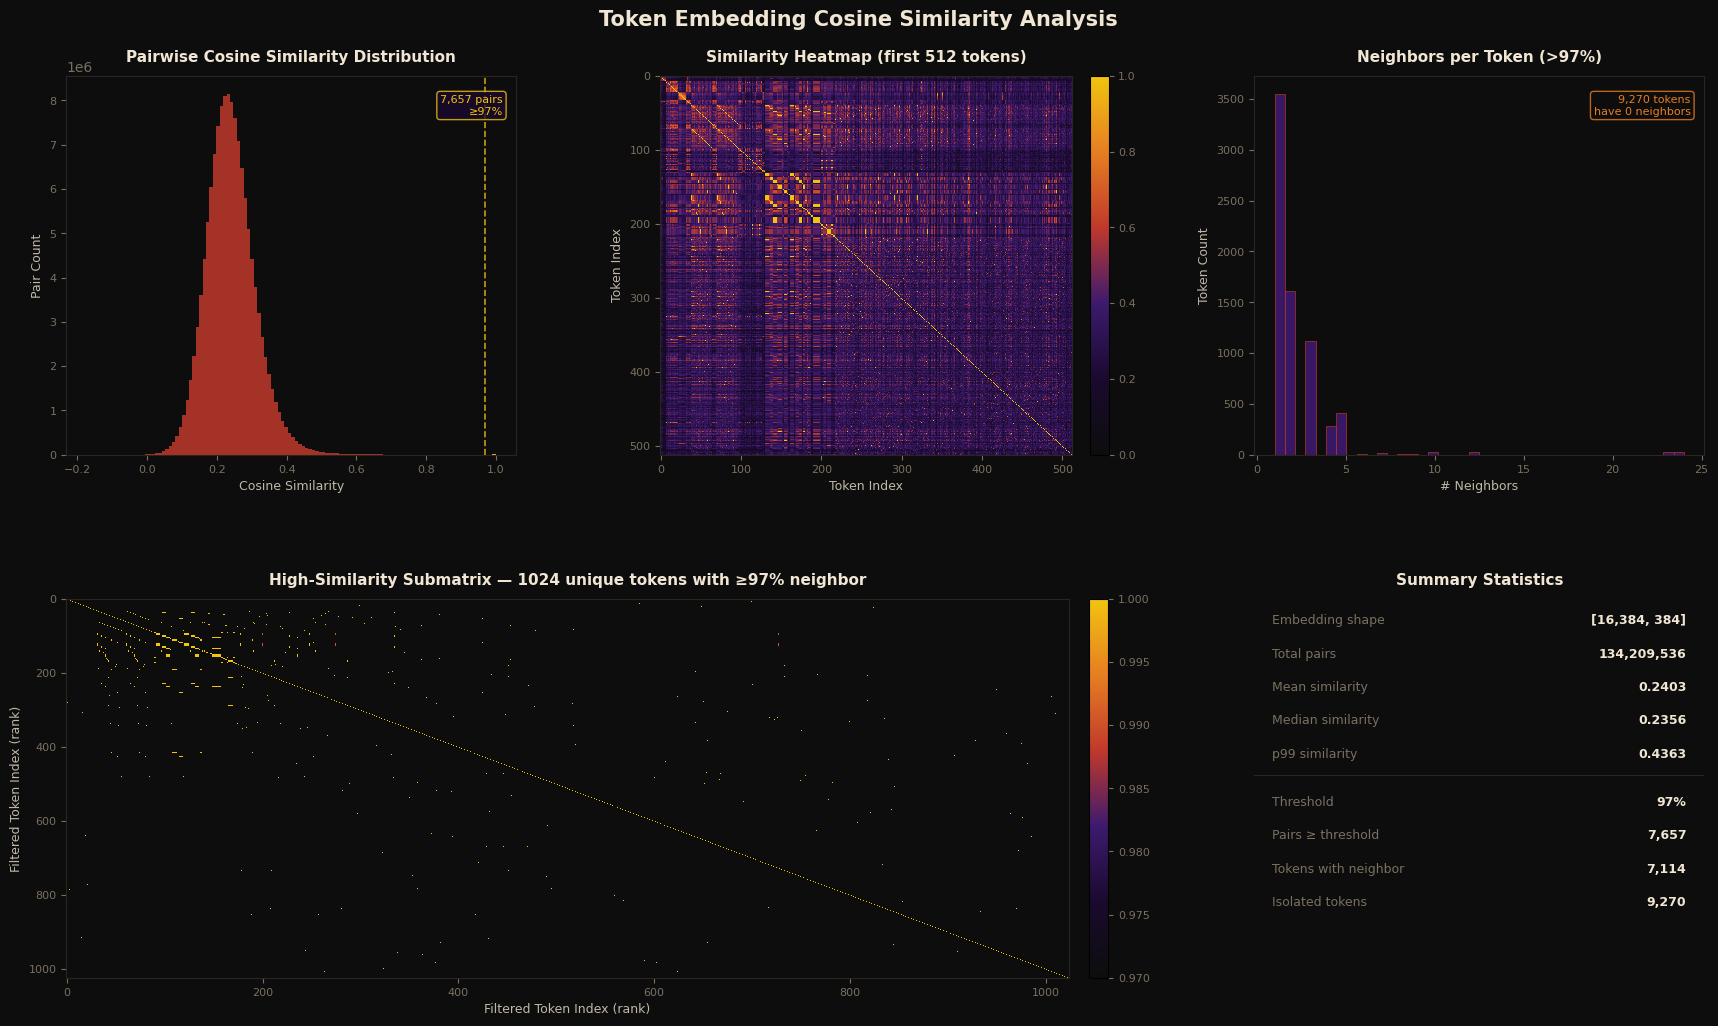

In [17]:
"""
cosine_similarity_analysis.py
──────────────────────────────
Computes all-pairs cosine similarity for a (N, D) token embedding tensor,
plots the distribution + a structural heatmap, and filters pairs > threshold.

Requires:
    embedding_tensor : torch.Tensor [N, D]
    tokenizer        : tokenizer object with get_vocab()
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import time

# ─── CONFIG ────────────────────────────────────────────────────────────────────
THRESHOLD       = 0.97       # similarity cutoff
HEATMAP_TOKENS  = 512        # how many tokens to show in the structural heatmap
BATCH_SIZE      = 512        # rows per batch for the full similarity computation
SAVE_PATH       = "cosine_analysis.png"
TOP_K_TOKENS    = 5          # top connected tokens to print
TOP_K_NEIGHBORS = 10         # neighbors printed per token
# ────────────────────────────────────────────────────────────────────────────────


# ─── REQUIRED DATA CHECK ────────────────────────────────────────────────────────
print("Checking required variables...")

if "embedding_tensor" not in globals():
    raise NameError(
        "embedding_tensor is not defined. "
        "Create/load your embedding_tensor before running this script."
    )

if "tok" not in globals():
    raise NameError(
        "tokenizer is not defined. "
        "Load/create your tokenizer before running this script."
    )

print(f"  tensor shape : {embedding_tensor.shape}")
# ────────────────────────────────────────────────────────────────────────────────


# ─── TOKEN LOOKUP ───────────────────────────────────────────────────────────────
vocab = tok.get_vocab()              # {token_str: token_id}
id_to_token = {v: k for k, v in vocab.items()}


def token_value(token_id: int) -> str:
    """
    Converts tokenizer ID into readable token text.

    Works well for ByteLevel BPE style tokens:
        Ġ  -> space
        Ċ  -> newline
    """
    tok = id_to_token.get(token_id, f"<missing:{token_id}>")

    tok = tok.replace("Ġ", " ")
    tok = tok.replace("Ċ", "\\n")

    return tok


def format_token(token_id: int, width: int = 22) -> str:
    """
    Pretty display for token id + token value.
    Uses repr() so spaces/newlines are visible.
    """
    value = repr(token_value(token_id))

    if len(value) > width:
        value = value[:width - 3] + "..."

    return f"token {token_id:5d} {value:<{width}}"
# ────────────────────────────────────────────────────────────────────────────────


def cosine_similarity_batched(embeddings: torch.Tensor, batch_size: int = 512):
    """
    Returns the full (N, N) cosine similarity matrix, computed in batches
    to avoid OOM on large tensors.

    Memory cost:
        N² × 4 bytes
        16384² × 4 ≈ 1 GB
    """
    # L2-normalise once — then cosine sim == dot product
    normed = torch.nn.functional.normalize(embeddings, p=2, dim=1)  # [N, D]
    N = normed.shape[0]
    sim = torch.zeros(N, N, dtype=torch.float32)

    t0 = time.time()

    for i in range(0, N, batch_size):
        batch = normed[i: i + batch_size]          # [B, D]
        sim[i: i + batch_size] = batch @ normed.T  # [B, N]

        if (i // batch_size) % 10 == 0:
            elapsed = time.time() - t0
            pct = min((i + batch_size) / N * 100, 100)
            print(f"  {pct:5.1f}%  {elapsed:.1f}s", end="\r")

    print(f"\n  Done in {time.time() - t0:.1f}s")

    return sim


def filter_high_similarity_pairs(sim: torch.Tensor, threshold: float = 0.90):
    """
    Returns:
        neighbors : dict[token_idx] -> list[(neighbor_idx, similarity_score)]
        rows      : source token ids
        cols      : neighbor token ids
        scores    : similarity scores

    Excludes the diagonal:
        self-similarity = 1.0
    """
    N = sim.shape[0]

    mask = sim > threshold
    mask.fill_diagonal_(False)

    rows, cols = torch.where(mask)
    scores = sim[rows, cols]

    neighbors = {}

    for r, c, s in zip(rows.tolist(), cols.tolist(), scores.tolist()):
        neighbors.setdefault(r, []).append((c, round(s, 4)))

    # Sort each neighbor list by descending similarity
    for k in neighbors:
        neighbors[k].sort(key=lambda x: -x[1])

    return neighbors, rows, cols, scores


def plot_analysis(
    sim: torch.Tensor,
    neighbors: dict,
    rows,
    cols,
    scores,
    threshold: float,
    heatmap_tokens: int = 512,
    save_path: str = None
):
    N = sim.shape[0]
    D = embedding_tensor.shape[1]
    total_pairs = N * (N - 1) // 2

    # ── flat upper-triangle for histogram, avoids double-counting
    idx_i, idx_j = torch.triu_indices(N, N, offset=1)
    all_sims = sim[idx_i, idx_j].numpy()

    # ── per-token neighbor counts
    counts = np.zeros(N, dtype=int)

    for k, v in neighbors.items():
        counts[k] = len(v)

    # ── colour map: dark background, warm gradient
    cmap_heat = LinearSegmentedColormap.from_list(
        "ember",
        ["#0d0d0d", "#1a0a2e", "#3d1a6e", "#c0392b", "#e67e22", "#f1c40f"]
    )

    fig = plt.figure(figsize=(18, 11), facecolor="#0d0d0d")

    gs = gridspec.GridSpec(
        2,
        3,
        figure=fig,
        left=0.06,
        right=0.97,
        top=0.91,
        bottom=0.09,
        hspace=0.38,
        wspace=0.32
    )

    title_kw = dict(color="#f0e6d3", fontsize=11, fontweight="bold", pad=10)
    label_kw = dict(color="#c0b8a8", fontsize=9)
    tick_kw = dict(colors="#7a7060", labelsize=8)
    spine_col = "#2a2520"

    def style_ax(ax):
        ax.set_facecolor("#0d0d0d")

        for spine in ax.spines.values():
            spine.set_color(spine_col)

        ax.tick_params(axis="both", **tick_kw)

    # ── 1. Histogram of all pairwise similarities
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1)

    n_bins = 120

    counts_hist, bin_edges, patches = ax1.hist(
        all_sims,
        bins=n_bins,
        color="#c0392b",
        alpha=0.85,
        edgecolor="none"
    )

    # Shade the >threshold zone
    for patch, left in zip(patches, bin_edges[:-1]):
        if left >= threshold:
            patch.set_facecolor("#f1c40f")
            patch.set_alpha(0.95)

    ax1.axvline(
        threshold,
        color="#f1c40f",
        linewidth=1.2,
        linestyle="--",
        alpha=0.8
    )

    ax1.set_title("Pairwise Cosine Similarity Distribution", **title_kw)
    ax1.set_xlabel("Cosine Similarity", **label_kw)
    ax1.set_ylabel("Pair Count", **label_kw)

    above = (all_sims >= threshold).sum()

    ax1.text(
        0.97,
        0.95,
        f"{above:,} pairs\n≥{threshold:.0%}",
        transform=ax1.transAxes,
        color="#f1c40f",
        fontsize=8,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#1a0a2e",
            ec="#f1c40f",
            alpha=0.8
        )
    )

    # ── 2. Structural heatmap
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2)

    sub = sim[:heatmap_tokens, :heatmap_tokens].numpy()

    im = ax2.imshow(
        sub,
        cmap=cmap_heat,
        vmin=0,
        vmax=1,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04).ax.tick_params(**tick_kw)

    ax2.set_title(f"Similarity Heatmap (first {heatmap_tokens} tokens)", **title_kw)
    ax2.set_xlabel("Token Index", **label_kw)
    ax2.set_ylabel("Token Index", **label_kw)

    # ── 3. Histogram of per-token neighbor count
    ax3 = fig.add_subplot(gs[0, 2])
    style_ax(ax3)

    non_zero_counts = counts[counts > 0]

    if len(non_zero_counts) > 0:
        ax3.hist(
            non_zero_counts,
            bins=40,
            color="#3d1a6e",
            edgecolor="#c0392b",
            linewidth=0.5,
            alpha=0.9
        )

    ax3.set_title(f"Neighbors per Token (>{threshold:.0%})", **title_kw)
    ax3.set_xlabel("# Neighbors", **label_kw)
    ax3.set_ylabel("Token Count", **label_kw)

    isolated = (counts == 0).sum()

    ax3.text(
        0.97,
        0.95,
        f"{isolated:,} tokens\nhave 0 neighbors",
        transform=ax3.transAxes,
        color="#e67e22",
        fontsize=8,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#0d0d0d",
            ec="#e67e22",
            alpha=0.8
        )
    )

    # ── 4. Filtered similarity matrix
    ax4 = fig.add_subplot(gs[1, :2])
    style_ax(ax4)

    high_tokens = sorted(set(rows.tolist()) | set(cols.tolist()))

    if len(high_tokens) > 1024:
        high_tokens = high_tokens[:1024]

    if len(high_tokens) > 1:
        idx_t = torch.tensor(high_tokens)
        sub_hi = sim[idx_t][:, idx_t].numpy()

        im2 = ax4.imshow(
            sub_hi,
            cmap=cmap_heat,
            vmin=threshold,
            vmax=1,
            aspect="auto",
            interpolation="nearest"
        )

        plt.colorbar(im2, ax=ax4, fraction=0.02, pad=0.02).ax.tick_params(**tick_kw)

        ax4.set_title(
            f"High-Similarity Submatrix — {len(high_tokens)} unique tokens with ≥{threshold:.0%} neighbor",
            **title_kw
        )

        ax4.set_xlabel("Filtered Token Index (rank)", **label_kw)
        ax4.set_ylabel("Filtered Token Index (rank)", **label_kw)

    else:
        ax4.text(
            0.5,
            0.5,
            "No high-similarity pairs found",
            transform=ax4.transAxes,
            color="#f0e6d3",
            ha="center",
            va="center",
            fontsize=13
        )

        ax4.set_title("High-Similarity Submatrix", **title_kw)

    # ── 5. Stats panel
    ax5 = fig.add_subplot(gs[1, 2])
    style_ax(ax5)
    ax5.axis("off")

    n_high_pairs = len(rows) // 2
    n_high_tokens = len(set(rows.tolist()))
    mean_sim = float(all_sims.mean())
    median_sim = float(np.median(all_sims))
    p99_sim = float(np.percentile(all_sims, 99))

    stats_lines = [
        ("Embedding shape", f"[{N:,}, {D}]"),
        ("Total pairs", f"{total_pairs:,}"),
        ("Mean similarity", f"{mean_sim:.4f}"),
        ("Median similarity", f"{median_sim:.4f}"),
        ("p99 similarity", f"{p99_sim:.4f}"),
        ("─" * 22, ""),
        ("Threshold", f"{threshold:.0%}"),
        ("Pairs ≥ threshold", f"{n_high_pairs:,}"),
        ("Tokens with neighbor", f"{n_high_tokens:,}"),
        ("Isolated tokens", f"{(counts == 0).sum():,}"),
    ]

    y = 0.96

    for label, value in stats_lines:
        if label.startswith("─"):
            ax5.axhline(y + 0.015, color=spine_col, linewidth=0.8)
            y -= 0.04
            continue

        ax5.text(
            0.04,
            y,
            label,
            transform=ax5.transAxes,
            color="#7a7060",
            fontsize=9,
            va="top"
        )

        ax5.text(
            0.96,
            y,
            value,
            transform=ax5.transAxes,
            color="#f0e6d3",
            fontsize=9,
            va="top",
            ha="right",
            fontweight="bold"
        )

        y -= 0.088

    ax5.set_title("Summary Statistics", **title_kw)

    fig.suptitle(
        "Token Embedding Cosine Similarity Analysis",
        color="#f0e6d3",
        fontsize=15,
        fontweight="bold",
        y=0.97
    )

    plt.savefig(
        save_path or SAVE_PATH,
        dpi=150,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    print(f"\nPlot saved → {save_path or SAVE_PATH}")
    plt.show()


# ─── MAIN ──────────────────────────────────────────────────────────────────────
print("\n[1/3] Computing full cosine similarity matrix …")

sim = cosine_similarity_batched(embedding_tensor, batch_size=BATCH_SIZE)

print(f"\n[2/3] Filtering pairs with similarity > {THRESHOLD} …")

neighbors, rows, cols, scores = filter_high_similarity_pairs(sim, THRESHOLD)

# ── what you "keep": a mapping from each token to its close neighbors
print(f"  Tokens with at least one neighbor : {len(neighbors):,}")
print(f"  Total directed edges              : {len(rows):,}")

# ── Print top connected tokens with token values
print(f"\n  Top-{TOP_K_TOKENS} most-connected tokens with token values:")

top_tokens = sorted(neighbors.items(), key=lambda x: -len(x[1]))[:TOP_K_TOKENS]

for tok_id, nbrs in top_tokens:
    tok_text = token_value(tok_id)

    print("\n" + "─" * 80)
    print(f"  {format_token(tok_id)}")
    print(f"  neighbors : {len(nbrs):,}")
    print(f"  top sim   : {nbrs[0][1]:.4f}")
    print(f"  top token : {format_token(nbrs[0][0])}")
    print("\n  Top neighbors:")

    for rank, (nb_id, sim_score) in enumerate(nbrs[:TOP_K_NEIGHBORS], start=1):
        print(
            f"    {rank:2d}. {format_token(nb_id)} "
            f"sim = {sim_score:.4f}"
        )

print("\n" + "─" * 80)

# ── kept_embeddings: the subset of embeddings involved in high-sim pairs
kept_indices = sorted(set(rows.tolist()) | set(cols.tolist()))
kept_embeddings = embedding_tensor[kept_indices]

print(f"\n  kept_embeddings.shape : {kept_embeddings.shape}")

# ── Optional: print kept token ids + values
print("\n  Sample kept token indices with values:")

for idx in kept_indices[:25]:
    print(f"    {format_token(idx)}")

if len(kept_indices) > 25:
    print(f"    ... and {len(kept_indices) - 25:,} more")

print("\n[3/3] Plotting …")

plot_analysis(
    sim,
    neighbors,
    rows,
    cols,
    scores,
    threshold=THRESHOLD,
    heatmap_tokens=HEATMAP_TOKENS,
    save_path=SAVE_PATH
)

In [16]:
model.to("cpu")

MicroLM(
  (token_embedding): Embedding(16384, 256)
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output_head): Linear(in_features=256, out_features=16384, bias=False)
)

In [17]:
embedding_tensor = model.token_embedding
embedding_tensor=  embedding_tensor.weight.detach()
embedding_tensor.shape

torch.Size([16384, 256])

Checking required variables...
  tensor shape : torch.Size([16384, 256])

[1/3] Computing full cosine similarity matrix …
   96.9%  0.4s
  Done in 0.4s

[2/3] Filtering pairs with similarity > 0.97 …
  Tokens with at least one neighbor : 0
  Total directed edges              : 0

  Top-5 most-connected tokens with token values:

────────────────────────────────────────────────────────────────────────────────

  kept_embeddings.shape : torch.Size([0, 256])

  Sample kept token indices with values:

[3/3] Plotting …

Plot saved → cosine_analysis.png


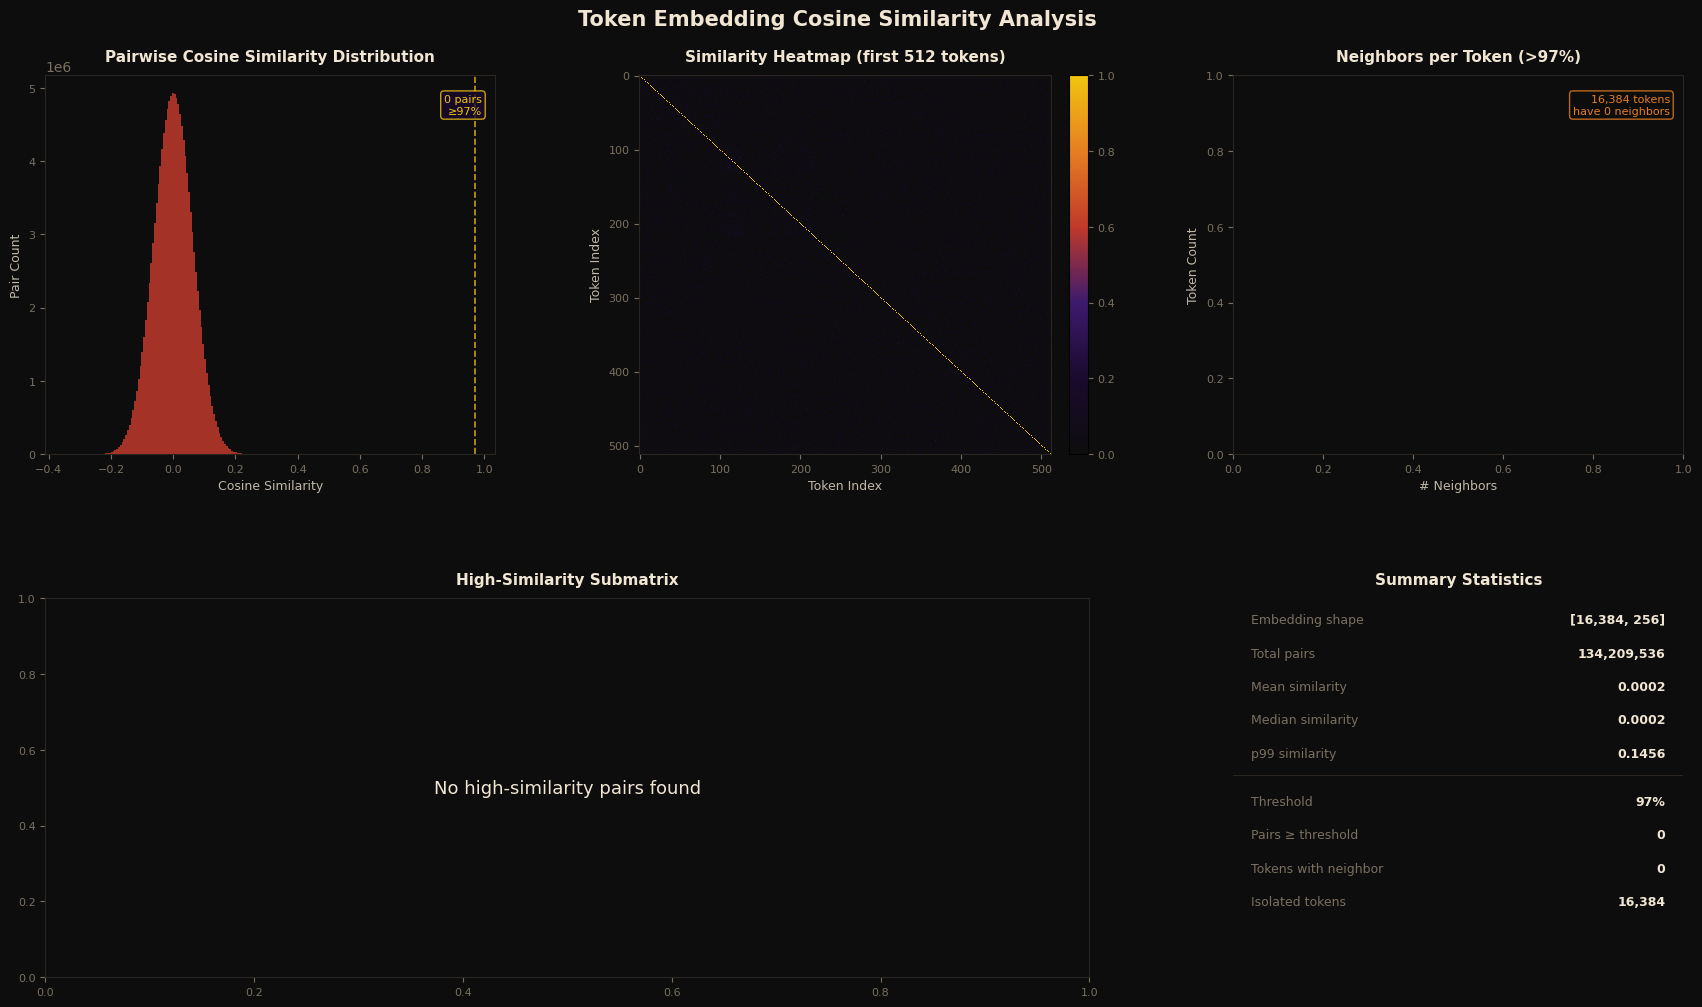

In [18]:
"""
cosine_similarity_analysis.py
──────────────────────────────
Computes all-pairs cosine similarity for a (N, D) token embedding tensor,
plots the distribution + a structural heatmap, and filters pairs > threshold.

Requires:
    embedding_tensor : torch.Tensor [N, D]
    tokenizer        : tokenizer object with get_vocab()
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import time

# ─── CONFIG ────────────────────────────────────────────────────────────────────
THRESHOLD       = 0.97       # similarity cutoff
HEATMAP_TOKENS  = 512        # how many tokens to show in the structural heatmap
BATCH_SIZE      = 512        # rows per batch for the full similarity computation
SAVE_PATH       = "cosine_analysis.png"
TOP_K_TOKENS    = 5          # top connected tokens to print
TOP_K_NEIGHBORS = 10         # neighbors printed per token
# ────────────────────────────────────────────────────────────────────────────────


# ─── REQUIRED DATA CHECK ────────────────────────────────────────────────────────
print("Checking required variables...")

if "embedding_tensor" not in globals():
    raise NameError(
        "embedding_tensor is not defined. "
        "Create/load your embedding_tensor before running this script."
    )

if "tok" not in globals():
    raise NameError(
        "tokenizer is not defined. "
        "Load/create your tokenizer before running this script."
    )

print(f"  tensor shape : {embedding_tensor.shape}")
# ────────────────────────────────────────────────────────────────────────────────


# ─── TOKEN LOOKUP ───────────────────────────────────────────────────────────────
vocab = tok.get_vocab()              # {token_str: token_id}
id_to_token = {v: k for k, v in vocab.items()}


def token_value(token_id: int) -> str:
    """
    Converts tokenizer ID into readable token text.

    Works well for ByteLevel BPE style tokens:
        Ġ  -> space
        Ċ  -> newline
    """
    tok = id_to_token.get(token_id, f"<missing:{token_id}>")

    tok = tok.replace("Ġ", " ")
    tok = tok.replace("Ċ", "\\n")

    return tok


def format_token(token_id: int, width: int = 22) -> str:
    """
    Pretty display for token id + token value.
    Uses repr() so spaces/newlines are visible.
    """
    value = repr(token_value(token_id))

    if len(value) > width:
        value = value[:width - 3] + "..."

    return f"token {token_id:5d} {value:<{width}}"
# ────────────────────────────────────────────────────────────────────────────────


def cosine_similarity_batched(embeddings: torch.Tensor, batch_size: int = 512):
    """
    Returns the full (N, N) cosine similarity matrix, computed in batches
    to avoid OOM on large tensors.

    Memory cost:
        N² × 4 bytes
        16384² × 4 ≈ 1 GB
    """
    # L2-normalise once — then cosine sim == dot product
    normed = torch.nn.functional.normalize(embeddings, p=2, dim=1)  # [N, D]
    N = normed.shape[0]
    sim = torch.zeros(N, N, dtype=torch.float32)

    t0 = time.time()

    for i in range(0, N, batch_size):
        batch = normed[i: i + batch_size]          # [B, D]
        sim[i: i + batch_size] = batch @ normed.T  # [B, N]

        if (i // batch_size) % 10 == 0:
            elapsed = time.time() - t0
            pct = min((i + batch_size) / N * 100, 100)
            print(f"  {pct:5.1f}%  {elapsed:.1f}s", end="\r")

    print(f"\n  Done in {time.time() - t0:.1f}s")

    return sim


def filter_high_similarity_pairs(sim: torch.Tensor, threshold: float = 0.90):
    """
    Returns:
        neighbors : dict[token_idx] -> list[(neighbor_idx, similarity_score)]
        rows      : source token ids
        cols      : neighbor token ids
        scores    : similarity scores

    Excludes the diagonal:
        self-similarity = 1.0
    """
    N = sim.shape[0]

    mask = sim > threshold
    mask.fill_diagonal_(False)

    rows, cols = torch.where(mask)
    scores = sim[rows, cols]

    neighbors = {}

    for r, c, s in zip(rows.tolist(), cols.tolist(), scores.tolist()):
        neighbors.setdefault(r, []).append((c, round(s, 4)))

    # Sort each neighbor list by descending similarity
    for k in neighbors:
        neighbors[k].sort(key=lambda x: -x[1])

    return neighbors, rows, cols, scores


def plot_analysis(
    sim: torch.Tensor,
    neighbors: dict,
    rows,
    cols,
    scores,
    threshold: float,
    heatmap_tokens: int = 512,
    save_path: str = None
):
    N = sim.shape[0]
    D = embedding_tensor.shape[1]
    total_pairs = N * (N - 1) // 2

    # ── flat upper-triangle for histogram, avoids double-counting
    idx_i, idx_j = torch.triu_indices(N, N, offset=1)
    all_sims = sim[idx_i, idx_j].numpy()

    # ── per-token neighbor counts
    counts = np.zeros(N, dtype=int)

    for k, v in neighbors.items():
        counts[k] = len(v)

    # ── colour map: dark background, warm gradient
    cmap_heat = LinearSegmentedColormap.from_list(
        "ember",
        ["#0d0d0d", "#1a0a2e", "#3d1a6e", "#c0392b", "#e67e22", "#f1c40f"]
    )

    fig = plt.figure(figsize=(18, 11), facecolor="#0d0d0d")

    gs = gridspec.GridSpec(
        2,
        3,
        figure=fig,
        left=0.06,
        right=0.97,
        top=0.91,
        bottom=0.09,
        hspace=0.38,
        wspace=0.32
    )

    title_kw = dict(color="#f0e6d3", fontsize=11, fontweight="bold", pad=10)
    label_kw = dict(color="#c0b8a8", fontsize=9)
    tick_kw = dict(colors="#7a7060", labelsize=8)
    spine_col = "#2a2520"

    def style_ax(ax):
        ax.set_facecolor("#0d0d0d")

        for spine in ax.spines.values():
            spine.set_color(spine_col)

        ax.tick_params(axis="both", **tick_kw)

    # ── 1. Histogram of all pairwise similarities
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1)

    n_bins = 120

    counts_hist, bin_edges, patches = ax1.hist(
        all_sims,
        bins=n_bins,
        color="#c0392b",
        alpha=0.85,
        edgecolor="none"
    )

    # Shade the >threshold zone
    for patch, left in zip(patches, bin_edges[:-1]):
        if left >= threshold:
            patch.set_facecolor("#f1c40f")
            patch.set_alpha(0.95)

    ax1.axvline(
        threshold,
        color="#f1c40f",
        linewidth=1.2,
        linestyle="--",
        alpha=0.8
    )

    ax1.set_title("Pairwise Cosine Similarity Distribution", **title_kw)
    ax1.set_xlabel("Cosine Similarity", **label_kw)
    ax1.set_ylabel("Pair Count", **label_kw)

    above = (all_sims >= threshold).sum()

    ax1.text(
        0.97,
        0.95,
        f"{above:,} pairs\n≥{threshold:.0%}",
        transform=ax1.transAxes,
        color="#f1c40f",
        fontsize=8,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#1a0a2e",
            ec="#f1c40f",
            alpha=0.8
        )
    )

    # ── 2. Structural heatmap
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2)

    sub = sim[:heatmap_tokens, :heatmap_tokens].numpy()

    im = ax2.imshow(
        sub,
        cmap=cmap_heat,
        vmin=0,
        vmax=1,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04).ax.tick_params(**tick_kw)

    ax2.set_title(f"Similarity Heatmap (first {heatmap_tokens} tokens)", **title_kw)
    ax2.set_xlabel("Token Index", **label_kw)
    ax2.set_ylabel("Token Index", **label_kw)

    # ── 3. Histogram of per-token neighbor count
    ax3 = fig.add_subplot(gs[0, 2])
    style_ax(ax3)

    non_zero_counts = counts[counts > 0]

    if len(non_zero_counts) > 0:
        ax3.hist(
            non_zero_counts,
            bins=40,
            color="#3d1a6e",
            edgecolor="#c0392b",
            linewidth=0.5,
            alpha=0.9
        )

    ax3.set_title(f"Neighbors per Token (>{threshold:.0%})", **title_kw)
    ax3.set_xlabel("# Neighbors", **label_kw)
    ax3.set_ylabel("Token Count", **label_kw)

    isolated = (counts == 0).sum()

    ax3.text(
        0.97,
        0.95,
        f"{isolated:,} tokens\nhave 0 neighbors",
        transform=ax3.transAxes,
        color="#e67e22",
        fontsize=8,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#0d0d0d",
            ec="#e67e22",
            alpha=0.8
        )
    )

    # ── 4. Filtered similarity matrix
    ax4 = fig.add_subplot(gs[1, :2])
    style_ax(ax4)

    high_tokens = sorted(set(rows.tolist()) | set(cols.tolist()))

    if len(high_tokens) > 1024:
        high_tokens = high_tokens[:1024]

    if len(high_tokens) > 1:
        idx_t = torch.tensor(high_tokens)
        sub_hi = sim[idx_t][:, idx_t].numpy()

        im2 = ax4.imshow(
            sub_hi,
            cmap=cmap_heat,
            vmin=threshold,
            vmax=1,
            aspect="auto",
            interpolation="nearest"
        )

        plt.colorbar(im2, ax=ax4, fraction=0.02, pad=0.02).ax.tick_params(**tick_kw)

        ax4.set_title(
            f"High-Similarity Submatrix — {len(high_tokens)} unique tokens with ≥{threshold:.0%} neighbor",
            **title_kw
        )

        ax4.set_xlabel("Filtered Token Index (rank)", **label_kw)
        ax4.set_ylabel("Filtered Token Index (rank)", **label_kw)

    else:
        ax4.text(
            0.5,
            0.5,
            "No high-similarity pairs found",
            transform=ax4.transAxes,
            color="#f0e6d3",
            ha="center",
            va="center",
            fontsize=13
        )

        ax4.set_title("High-Similarity Submatrix", **title_kw)

    # ── 5. Stats panel
    ax5 = fig.add_subplot(gs[1, 2])
    style_ax(ax5)
    ax5.axis("off")

    n_high_pairs = len(rows) // 2
    n_high_tokens = len(set(rows.tolist()))
    mean_sim = float(all_sims.mean())
    median_sim = float(np.median(all_sims))
    p99_sim = float(np.percentile(all_sims, 99))

    stats_lines = [
        ("Embedding shape", f"[{N:,}, {D}]"),
        ("Total pairs", f"{total_pairs:,}"),
        ("Mean similarity", f"{mean_sim:.4f}"),
        ("Median similarity", f"{median_sim:.4f}"),
        ("p99 similarity", f"{p99_sim:.4f}"),
        ("─" * 22, ""),
        ("Threshold", f"{threshold:.0%}"),
        ("Pairs ≥ threshold", f"{n_high_pairs:,}"),
        ("Tokens with neighbor", f"{n_high_tokens:,}"),
        ("Isolated tokens", f"{(counts == 0).sum():,}"),
    ]

    y = 0.96

    for label, value in stats_lines:
        if label.startswith("─"):
            ax5.axhline(y + 0.015, color=spine_col, linewidth=0.8)
            y -= 0.04
            continue

        ax5.text(
            0.04,
            y,
            label,
            transform=ax5.transAxes,
            color="#7a7060",
            fontsize=9,
            va="top"
        )

        ax5.text(
            0.96,
            y,
            value,
            transform=ax5.transAxes,
            color="#f0e6d3",
            fontsize=9,
            va="top",
            ha="right",
            fontweight="bold"
        )

        y -= 0.088

    ax5.set_title("Summary Statistics", **title_kw)

    fig.suptitle(
        "Token Embedding Cosine Similarity Analysis",
        color="#f0e6d3",
        fontsize=15,
        fontweight="bold",
        y=0.97
    )

    plt.savefig(
        save_path or SAVE_PATH,
        dpi=150,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    print(f"\nPlot saved → {save_path or SAVE_PATH}")
    plt.show()


# ─── MAIN ──────────────────────────────────────────────────────────────────────
print("\n[1/3] Computing full cosine similarity matrix …")

sim = cosine_similarity_batched(embedding_tensor, batch_size=BATCH_SIZE)

print(f"\n[2/3] Filtering pairs with similarity > {THRESHOLD} …")

neighbors, rows, cols, scores = filter_high_similarity_pairs(sim, THRESHOLD)

# ── what you "keep": a mapping from each token to its close neighbors
print(f"  Tokens with at least one neighbor : {len(neighbors):,}")
print(f"  Total directed edges              : {len(rows):,}")

# ── Print top connected tokens with token values
print(f"\n  Top-{TOP_K_TOKENS} most-connected tokens with token values:")

top_tokens = sorted(neighbors.items(), key=lambda x: -len(x[1]))[:TOP_K_TOKENS]

for tok_id, nbrs in top_tokens:
    tok_text = token_value(tok_id)

    print("\n" + "─" * 80)
    print(f"  {format_token(tok_id)}")
    print(f"  neighbors : {len(nbrs):,}")
    print(f"  top sim   : {nbrs[0][1]:.4f}")
    print(f"  top token : {format_token(nbrs[0][0])}")
    print("\n  Top neighbors:")

    for rank, (nb_id, sim_score) in enumerate(nbrs[:TOP_K_NEIGHBORS], start=1):
        print(
            f"    {rank:2d}. {format_token(nb_id)} "
            f"sim = {sim_score:.4f}"
        )

print("\n" + "─" * 80)

# ── kept_embeddings: the subset of embeddings involved in high-sim pairs
kept_indices = sorted(set(rows.tolist()) | set(cols.tolist()))
kept_embeddings = embedding_tensor[kept_indices]

print(f"\n  kept_embeddings.shape : {kept_embeddings.shape}")

# ── Optional: print kept token ids + values
print("\n  Sample kept token indices with values:")

for idx in kept_indices[:25]:
    print(f"    {format_token(idx)}")

if len(kept_indices) > 25:
    print(f"    ... and {len(kept_indices) - 25:,} more")

print("\n[3/3] Plotting …")

plot_analysis(
    sim,
    neighbors,
    rows,
    cols,
    scores,
    threshold=THRESHOLD,
    heatmap_tokens=HEATMAP_TOKENS,
    save_path=SAVE_PATH
)